# Historical Trend Analysis
This section covers all data visualizations found within 2.2.2 Historical Trend Analysis

For income, we used annual per-capita disposable income as it's post-tax and post-contribution, so it reflects what households actually have available to spend on housing. For housing prices, we took the average purchase price per square meter across all districts to match the income data at the city level.

### 1. Income growth vs housing price growth (2016-2025)

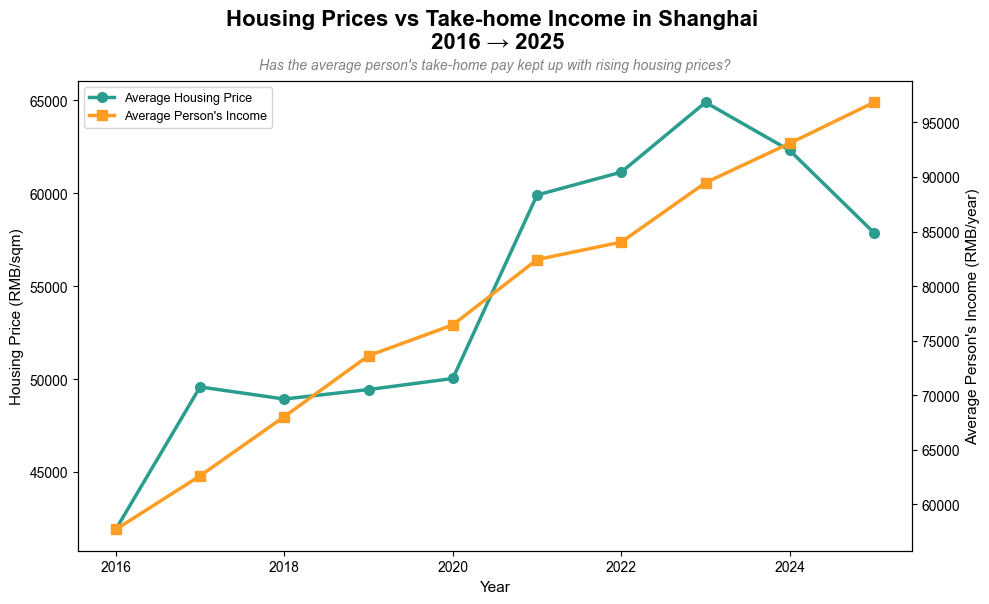

In [ ]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path


project_root = Path.cwd().parent
data_dir = project_root / "data"

years_housing = []
prices_housing = []

with open(data_dir / "shanghai_housing_prices_annual.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        year = int(row["year"])
        if year >= 2016:
            years_housing.append(year)
            prices_housing.append(float(row["avg_annual_price_per_sqm"]))

unique_years = sorted(set(years_housing))
avg_price_by_year = []

for year in unique_years:
    total = 0
    count = 0
    for i in range(len(years_housing)):
        if years_housing[i] == year:
            total = total + prices_housing[i]
            count = count + 1
    avg_price_by_year.append(total / count)

years_income = []
income_values = []

with open(data_dir / "shanghai_income_final.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        year = int(row["year"])
        if year >= 2016:
            years_income.append(year)
            income_values.append(float(row["urban_disposable_income_per_capita"]))

income_sorted = sorted(zip(years_income, income_values))
years_income_sorted = [pair[0] for pair in income_sorted]
income_sorted_values = [pair[1] for pair in income_sorted]


SDG_YELLOW  = "#FD9D24"
TEAL        = "#2A9D8F"
DARK_BLUE   = "#264653"
SOFT_ORANGE = "#F4A261"
ACCENT_RED  = "#E76F51"

plt.rcParams['font.family'] = 'Arial'

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(unique_years, avg_price_by_year, color=TEAL, marker="o", linewidth=2.5, markersize=7, label="Average Housing Price")
ax1.set_xlabel("Year", fontsize=11)
ax1.set_ylabel("Housing Price (RMB/sqm)", fontsize=11)
ax1.tick_params(axis='y')

ax2 = ax1.twinx()
ax2.plot(years_income_sorted, income_sorted_values, color=SDG_YELLOW, marker="s", linewidth=2.5, markersize=7, label="Average Person's Income")
ax2.set_ylabel("Average Person's Income (RMB/year)", fontsize=11)
ax2.tick_params(axis='y')

plt.suptitle("Housing Prices vs Take-home Income in Shanghai \n 2016 → 2025", fontsize=16, fontweight='bold', ha='center', y=1)
fig.text(0.5, 0.90, "Has the average person's take-home pay kept up with rising housing prices?", 
         fontsize=10,color='grey', ha='center', style='italic')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=9)

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

### 2. New housing price trend by district (2016-2025)

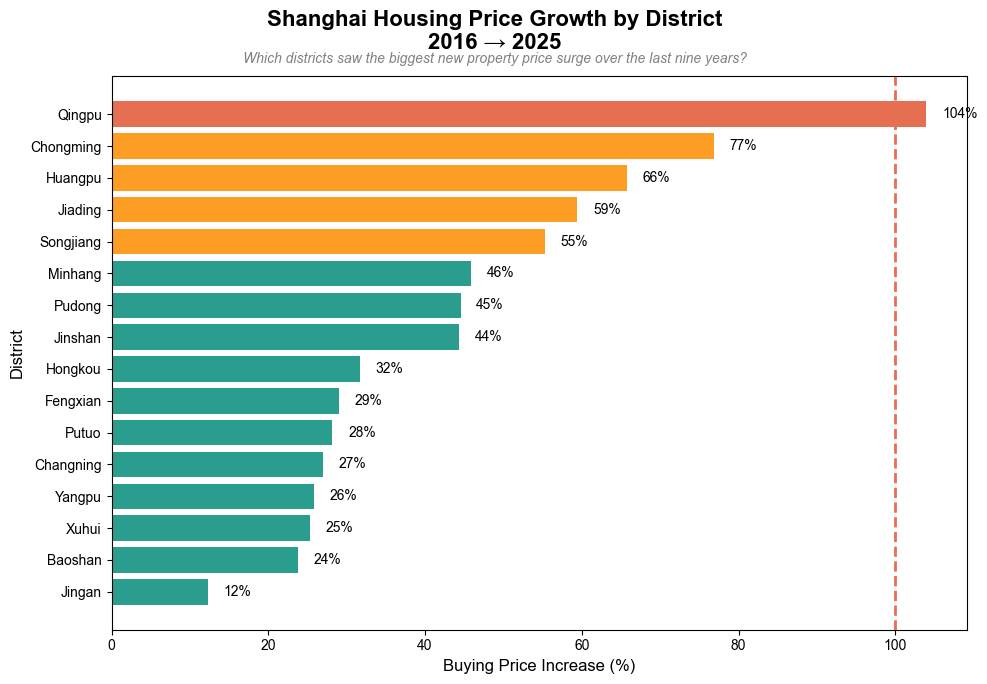

In [ ]:
import csv
import matplotlib.pyplot as plt
from pathlib import Path

project_root = Path.cwd().parent
data_dir = project_root / "data"

plt.rcParams['font.family'] = 'Arial'

districts = []
years = []
prices = []

with open(data_dir / "shanghai_housing_prices_annual.csv", "r", encoding="utf-8-sig") as file:
    reader = csv.DictReader(file)
    for row in reader:
        year = int(row["year"])
        if 2016 <= year <= 2025:
            districts.append(row["district"])
            years.append(year)
            prices.append(float(row["avg_annual_price_per_sqm"]))

unique_districts = []
for d in districts:
    if d not in unique_districts:
        unique_districts.append(d)
unique_districts.sort()

price_2016 = []
price_2025 = []

for d in unique_districts:
    price_2016_val = 0
    price_2025_val = 0
    for i in range(len(districts)):
        if districts[i] == d and years[i] == 2016:
            price_2016_val = prices[i]
        if districts[i] == d and years[i] == 2025:
            price_2025_val = prices[i]
    
    if price_2016_val > 0 and price_2025_val > 0:
        price_2016.append(price_2016_val)
        price_2025.append(price_2025_val)

growth = []
for i in range(len(price_2016)):
    g = (price_2025[i] - price_2016[i]) / price_2016[i] * 100
    growth.append(g)

for i in range(len(growth)):
    for j in range(i + 1, len(growth)):
        if growth[i] < growth[j]:
            growth[i], growth[j] = growth[j], growth[i]
            unique_districts[i], unique_districts[j] = unique_districts[j], unique_districts[i]
            price_2016[i], price_2016[j] = price_2016[j], price_2016[i]
            price_2025[i], price_2025[j] = price_2025[j], price_2025[i]

fig, ax = plt.subplots(figsize=(10, 7))


colors = []
for g in growth:
    if g >= 100:
        colors.append(ACCENT_RED)
    elif g >= 50:
        colors.append(SDG_YELLOW)
    else:
        colors.append(TEAL)

bars = ax.barh(unique_districts, growth, color=colors)
for i in range(len(bars)):
    ax.text(bars[i].get_width() + 2, bars[i].get_y() + bars[i].get_height()/2, 
            f'{growth[i]:.0f}%', va='center', fontsize=10)

ax.axvline(x=100, color=ACCENT_RED, linestyle='--', linewidth=2)

ax.set_xlabel('Buying Price Increase (%)', fontsize=12)
ax.set_ylabel('District', fontsize=12)

fig.suptitle(
    'Shanghai Housing Price Growth by District\n2016 → 2025', fontsize=16, fontweight='bold', x=0.5, y=0.97, ha='center'
)

fig.text( 0.5, 0.90,
    'Which districts saw the biggest new property price surge over the last nine years?',  fontsize=10,ha='center', va='center', style='italic', color='grey'
)

fig.subplots_adjust(top=1)

ax.invert_yaxis()

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### 3. Price-to-Income ratio trend (2016-2025)

In [ ]:

import csv
from pathlib import Path

project_root = Path.cwd().parent
data_dir = project_root / "data"

years_housing = []
prices_housing = []

with open(data_dir /   "shanghai_housing_prices_annual.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        years_housing.append(int(row["year"]))
        prices_housing.append(float(row["avg_annual_price_per_sqm"]))


unique_years = sorted(set(years_housing))
avg_price_by_year = []

for year in unique_years:
    total = 0
    count = 0
    for i in range(len(years_housing)):
        if years_housing[i] == year:
            total = total + prices_housing[i]
            count = count + 1
    avg_price_by_year.append(total / count)

years_income = []
income_values = []

with open("shanghai_income_final.csv", "r") as file:
    reader = csv.DictReader(file)
    for row in reader:
        years_income.append(int(row["year"]))
        income_values.append(float(row["urban_disposable_income_per_capita"]))

income_sorted = sorted(zip(years_income, income_values))
years_income_sorted = [pair[0] for pair in income_sorted]
income_sorted_values = [pair[1] for pair in income_sorted]

aligned_years = []
aligned_avg_prices = []
aligned_incomes = []

for i in range(len(unique_years)):
    if unique_years[i] in years_income_sorted:
        income_idx = years_income_sorted.index(unique_years[i])
        aligned_years.append(unique_years[i])
        aligned_avg_prices.append(avg_price_by_year[i])
        aligned_incomes.append(income_sorted_values[income_idx])

ratio_list = []
for i in range(len(aligned_years)):
    ratio = aligned_avg_prices[i] / aligned_incomes[i]
    ratio_list.append(ratio)


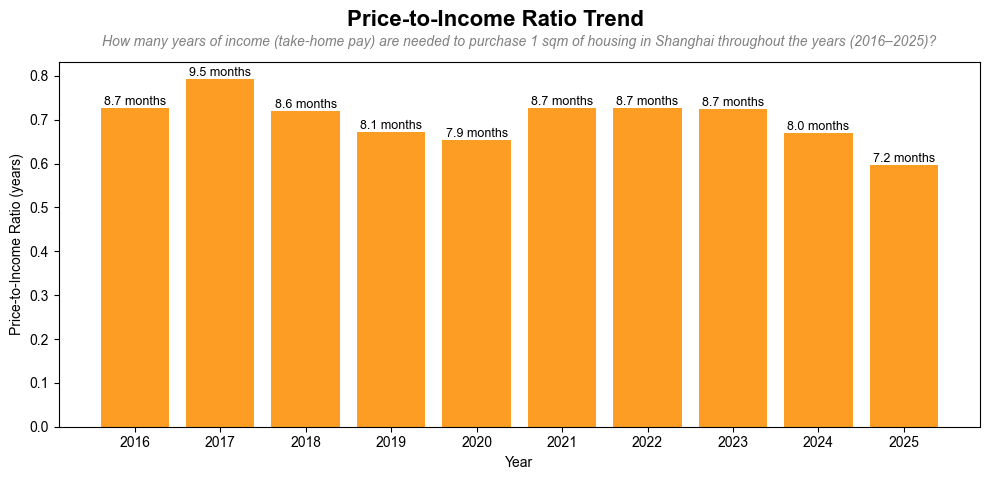

In [14]:

import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Arial'

plt.figure(figsize=(10, 5))

plt.bar(aligned_years, ratio_list, color=SDG_YELLOW)

plt.xticks(aligned_years)

for x, y in zip(aligned_years, ratio_list):
    months = y * 12
    plt.text(
        x,
        y,
        f"{months:.1f} months",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.suptitle("Price-to-Income Ratio Trend", fontsize=16, fontweight="bold", y=0.95)
plt.title("How many years of income (take-home pay) are needed to purchase 1 sqm of housing in Shanghai throughout the years (2016–2025)?", fontsize=10, color="grey",
    fontstyle="italic", y=1.02)

plt.xlabel("Year")
plt.ylabel("Price-to-Income Ratio (years)")
plt.tight_layout()
plt.show()